##### Importing Libraries

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
)

import statsmodels.api as sm

##### Importing Zillow Home Value Index (ZHVI) dataset

In [39]:
zillow_hv_index = pd.read_csv("../data/raw/Zillow/zillow_home_value_index.csv")

##### Initial Overview

In [42]:
metadata_df = zillow_hv_index.iloc[:, :5]
monthly_values_df = zillow_hv_index.iloc[:, 5:]

print(
    f"""=== Dataset Dimensions ===
Rows: {zillow_hv_index.shape[0]:,}
Columns: {zillow_hv_index.shape[1]:,}

=== Dataset Structure ===
Metadata Columns: {metadata_df.shape[1]}
Monthly Value Columns: {monthly_values_df.shape[1]}
"""
)

print("=== Monthly Values Overview ===")
monthly_values_df.info()

print("\n=== Metadata Overview ===")
metadata_df.info()

=== Dataset Dimensions ===
Rows: 895
Columns: 322

=== Dataset Structure ===
Metadata Columns: 5
Monthly Value Columns: 317

=== Monthly Values Overview ===
<class 'pandas.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Columns: 317 entries, 2000-01-31 to 2026-05-31
dtypes: float64(317)
memory usage: 2.2 MB

=== Metadata Overview ===
<class 'pandas.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   RegionID    895 non-null    int64
 1   SizeRank    895 non-null    int64
 2   RegionName  895 non-null    str  
 3   RegionType  895 non-null    str  
 4   StateName   894 non-null    str  
dtypes: int64(2), str(3)
memory usage: 35.1 KB


##### Data Cleaning

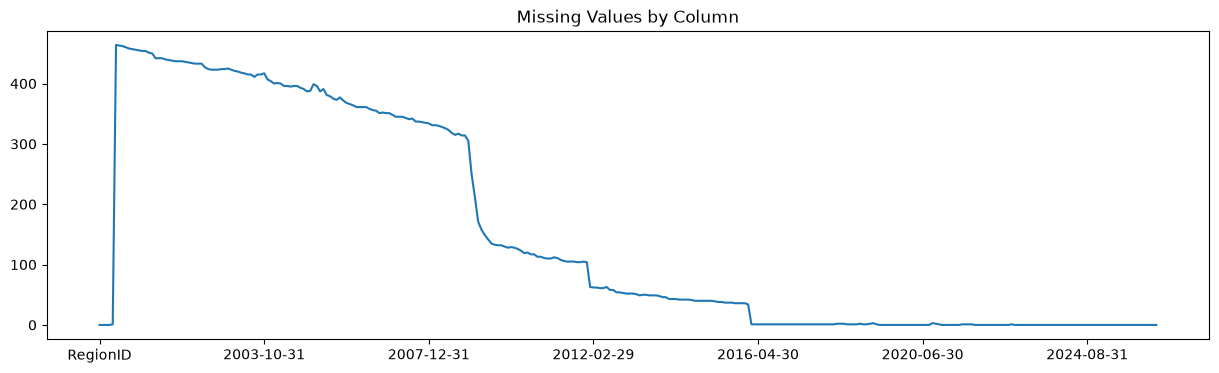

In [46]:
missing = zillow_hv_index.isna().sum()

missing.plot(figsize=(15,4))
plt.title("Missing Values by Column")
plt.show()

In [47]:
missing_pct = (
    zillow_hv_index
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

missing_pct.head(20)

2000-01-31    51.84
2000-02-29    51.73
2000-03-31    51.62
2000-04-30    51.40
2000-05-31    51.17
2000-06-30    51.06
2000-07-31    50.95
2000-08-31    50.84
2000-09-30    50.73
2000-10-31    50.73
2000-11-30    50.39
2000-12-31    50.28
2001-02-28    49.39
2001-03-31    49.39
2001-01-31    49.39
2001-04-30    49.16
2001-05-31    49.05
2001-06-30    48.94
2001-08-31    48.83
2001-07-31    48.83
dtype: float64

In [48]:
zillow_hv_index[
    zillow_hv_index["2000-01-31"].isna()
].head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
33,394705,34,"Indianapolis, IN",msa,IN,NaN,NaN,NaN,NaN,NaN,...,292453.265323,292805.770722,293044.429863,293516.810988,294169.201154,294943.873505,295699.920234,296201.774989,296280.676381,295921.276058
61,394312,62,"Albuquerque, NM",msa,NM,NaN,NaN,NaN,NaN,NaN,...,348642.764200,348862.916261,349321.900225,350013.334982,350759.658832,351516.470434,352089.979383,352517.308197,352676.645256,352894.320742
65,394367,66,"Baton Rouge, LA",msa,LA,NaN,NaN,NaN,NaN,NaN,...,242538.706502,242353.558883,242736.405425,243393.678157,244315.036617,245333.514008,246603.179406,247587.280365,248109.716971,248175.797162
66,394843,67,"McAllen, TX",msa,TX,NaN,NaN,NaN,NaN,NaN,...,193026.060351,193410.814381,193221.278656,193022.801498,193204.004347,193881.825245,194522.513611,194884.254047,194663.237634,193978.291841
77,394399,79,"Boise City, ID",msa,ID,NaN,NaN,NaN,NaN,NaN,...,492096.745436,493221.037833,495050.506829,497194.011378,499173.158104,500657.756257,501226.463010,500177.857352,498190.440165,496287.934203
